# 🌧️ Rain in Australia — Prediction
Задача: передбачити чи буде дощ завтра на основі сьогоднішніх погодних даних.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

## 1. Завантаження даних

In [2]:
df = pd.read_csv('weatherAUS.csv')
df.shape

(145460, 23)

In [3]:
df.head(3)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No


In [4]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


## 2. EDA

In [5]:
# пропуски
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'count': missing, 'percent': missing_pct})[missing > 0]

,count,percent
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


In [6]:
# розподіл цільової змінної
df['RainTomorrow'].value_counts()

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

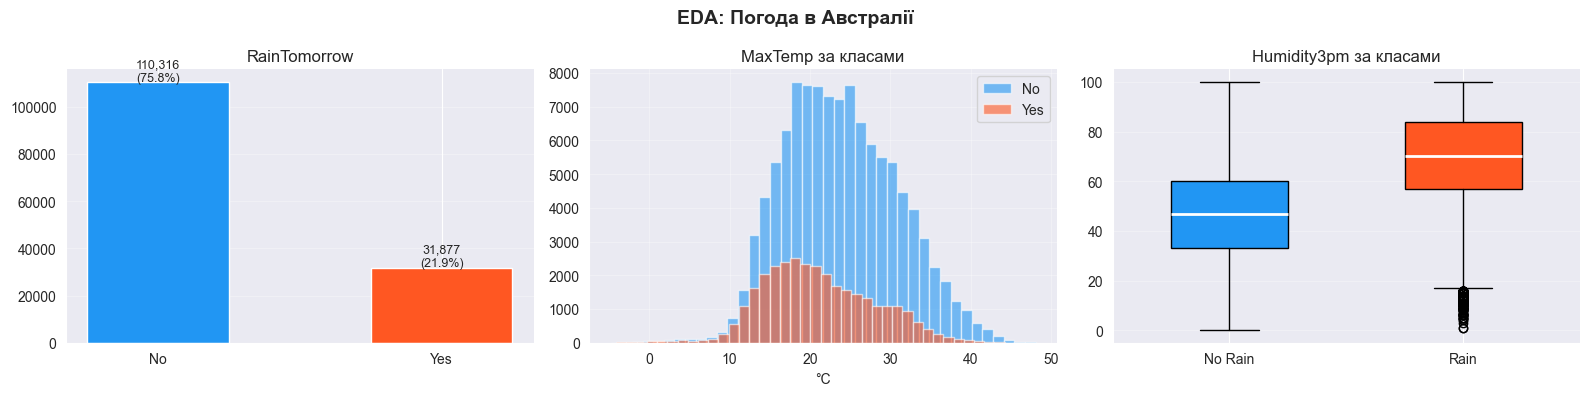

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('EDA: Погода в Австралії', fontsize=14, fontweight='bold')

# розподіл таргету
rain_counts = df['RainTomorrow'].value_counts()
axes[0].bar(rain_counts.index, rain_counts.values, color=['#2196F3', '#FF5722'], edgecolor='white', width=0.5)
axes[0].set_title('RainTomorrow')
for i, v in enumerate(rain_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# температура по класах
df_c = df.dropna(subset=['MaxTemp', 'RainTomorrow'])
axes[1].hist(df_c[df_c['RainTomorrow']=='No']['MaxTemp'], bins=40, alpha=0.6, color='#2196F3', label='No')
axes[1].hist(df_c[df_c['RainTomorrow']=='Yes']['MaxTemp'], bins=40, alpha=0.6, color='#FF5722', label='Yes')
axes[1].set_title('MaxTemp за класами')
axes[1].set_xlabel('°C')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

# вологість boxplot
df_h = df.dropna(subset=['Humidity3pm', 'RainTomorrow'])
bp = axes[2].boxplot(
    [df_h[df_h['RainTomorrow']=='No']['Humidity3pm'], df_h[df_h['RainTomorrow']=='Yes']['Humidity3pm']],
    patch_artist=True, widths=0.5,
    medianprops=dict(color='white', linewidth=2)
)
bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][1].set_facecolor('#FF5722')
axes[2].set_xticklabels(['No Rain', 'Rain'])
axes[2].set_title('Humidity3pm за класами')
axes[2].grid(axis='y', alpha=0.3)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

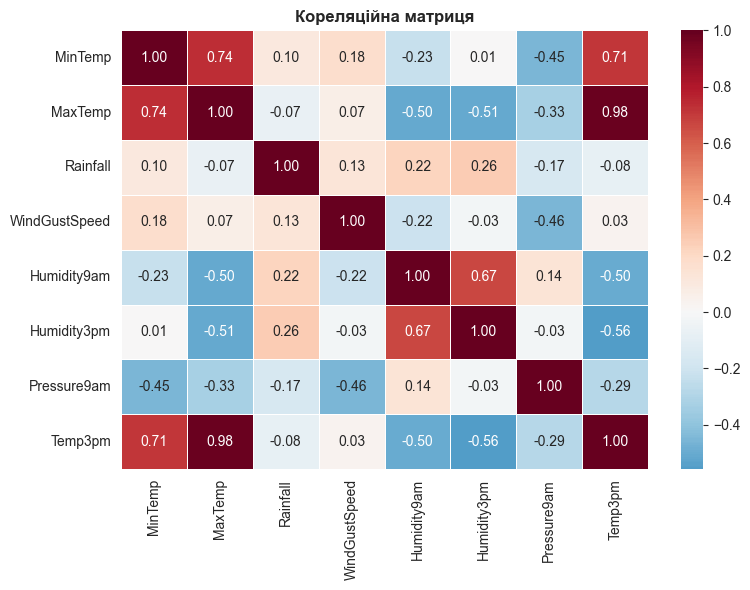

In [8]:
# кореляційна матриця
num_cols_corr = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
                 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Temp3pm']

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols_corr].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Кореляційна матриця', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Передобробка

In [9]:
df = df.dropna(subset=['RainTomorrow'])

# витягуємо місяць і прибираємо Date
df['Month'] = pd.to_datetime(df['Date']).dt.month.astype(str)
df = df.drop(columns=['Date'])

In [10]:
cat_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Month']
num_cols = [c for c in df.columns if c not in cat_cols + ['RainTomorrow']]

# заповнення пропусків: медіана для числових, мода для категоріальних
df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])
df[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df[cat_cols])

df.isnull().sum().sum()  # має бути 0

np.int64(0)

In [11]:
# label encoding для категоріальних
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df['RainTomorrow'] = (df['RainTomorrow'] == 'Yes').astype(int)

df[cat_cols + ['RainTomorrow']].head(3)

,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,Month,RainTomorrow
0,2,13,13,14,0,3,0
1,2,14,6,15,0,3,0
2,2,15,13,15,0,3,0


## 4. Навчання моделей

In [12]:
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# масштабування для логістичної регресії
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')

Train: 113754  |  Test: 28439


In [13]:
# baseline — логістична регресія
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

lr_preds = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

print(f'Logistic Regression  AUC: {roc_auc_score(y_test, lr_proba):.4f}')
print(classification_report(y_test, lr_preds, target_names=['No Rain', 'Rain']))

Logistic Regression  AUC: 0.8670
              precision    recall  f1-score   support

     No Rain       0.87      0.95      0.90     22064
        Rain       0.73      0.49      0.59      6375

    accuracy                           0.85     28439
   macro avg       0.80      0.72      0.75     28439
weighted avg       0.84      0.85      0.83     28439



In [14]:
# основна модель — Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',  # враховуємо дисбаланс
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print(f'Random Forest  AUC: {roc_auc_score(y_test, rf_proba):.4f}')
print(classification_report(y_test, rf_preds, target_names=['No Rain', 'Rain']))

Random Forest  AUC: 0.8867
              precision    recall  f1-score   support

     No Rain       0.91      0.87      0.89     22064
        Rain       0.62      0.71      0.66      6375

    accuracy                           0.84     28439
   macro avg       0.76      0.79      0.78     28439
weighted avg       0.85      0.84      0.84     28439



## 5. Результати

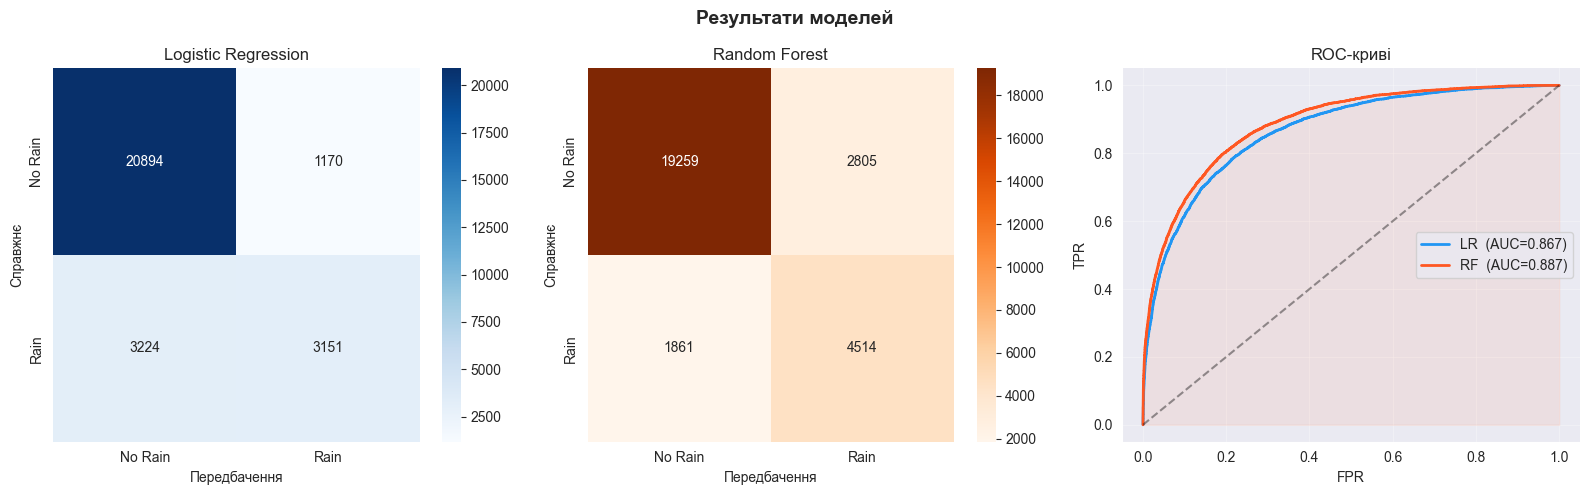

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Результати моделей', fontsize=14, fontweight='bold')

# confusion matrix — LR
cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Передбачення')
axes[0].set_ylabel('Справжнє')

# confusion matrix — RF
cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Передбачення')
axes[1].set_ylabel('Справжнє')

# ROC-криві
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
axes[2].plot(fpr_lr, tpr_lr, color='#2196F3', lw=2, label=f'LR  (AUC={roc_auc_score(y_test, lr_proba):.3f})')
axes[2].plot(fpr_rf, tpr_rf, color='#FF5722', lw=2, label=f'RF  (AUC={roc_auc_score(y_test, rf_proba):.3f})')
axes[2].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[2].fill_between(fpr_rf, tpr_rf, alpha=0.08, color='#FF5722')
axes[2].set_title('ROC-криві')
axes[2].set_xlabel('FPR')
axes[2].set_ylabel('TPR')
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

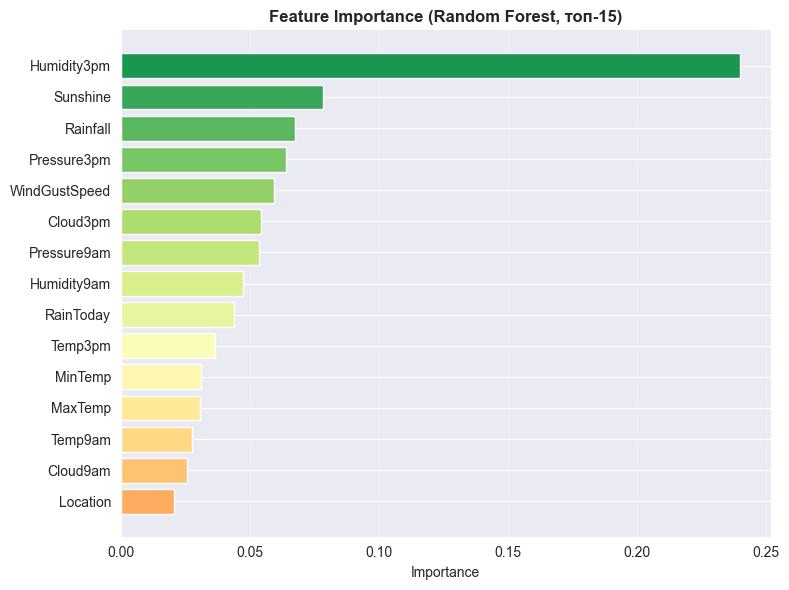

In [16]:
# важливість ознак
feat_imp = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})\
             .sort_values('importance', ascending=True).tail(15)

plt.figure(figsize=(8, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_imp)))
plt.barh(feat_imp['feature'], feat_imp['importance'], color=colors, edgecolor='white')
plt.title('Feature Importance (Random Forest, топ-15)', fontweight='bold')
plt.xlabel('Importance')
plt.grid(axis='x', alpha=0.3)
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [17]:
feat_imp.sort_values('importance', ascending=False).head(10)

,feature,importance
13,Humidity3pm,0.239683
5,Sunshine,0.078447
3,Rainfall,0.067460
15,Pressure3pm,0.063839
7,WindGustSpeed,0.059189
17,Cloud3pm,0.054211
14,Pressure9am,0.053377
12,Humidity9am,0.047427
20,RainToday,0.043759
19,Temp3pm,0.036404
